# Lab Instructions

You have been hired by James Cameron to create profiles of two characters for a reboot of the Titanic Movie: one that is most likely to survive the sinking and one that is least likely to survive.  Mr. Cameron wants this reboot to be as historically accurate as possible, so your profile of each character should be backed up with data and visualizations.

Each character profile should include information on their:
* Age, fare
* Sex
* Passenger class
* Travel companions (including both parents/children and siblings/spouse)
* Port of departure

For quantitative features like `Age` and `Fare`, you will need to use the `.loc` method we learned in class (or something similar) to place individuals in categories.  How you choose to do this is up to you, but make sure you explain your reasoning.

You should include at least one visualization for each element of the character profile (age, sex, passenger class, etc.) as evidence.

After you have developed your two character profiles, use your Pandas data wrangling skills to identify at least one real passenger in the dataset that fits each profile.  Print out the names of these individuals.  Look them up in [Encyclopeida Titanica](https://www.encyclopedia-titanica.org/) (or a similar resource).  

Tell Mr. Cameron at least one thing about the real passengers who fit your two character profiles that you learned from an external resource.  You need one interesting fact about a person who fits the profile of "most likely to survive" and one interesting fact about a person who fits the profile of "least likely to surivive".  



In [4]:
import pandas as pd

In [5]:
df = pd.read_csv('titanic_passengers.csv')
df.head()

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S


In [6]:
df['Age'].value_counts()

Age
24.00    30
22.00    27
18.00    26
28.00    25
30.00    25
         ..
24.50     1
0.67      1
0.42      1
34.50     1
74.00     1
Name: count, Length: 88, dtype: int64

In [27]:
df.loc[df['Age'] <= 18, 'Age_cat'] = 0
df.loc[(df['Age'] <= 65) & (df['Age'] > 18), 'Age_cat'] = 1
df.loc[df['Age'] > 65, 'Age_cat'] = 2

pd.crosstab(df['Age'], df['Age_cat'])

Age_cat,0.0,1.0,2.0
Age,,,
0.42,1,0,0
0.67,1,0,0
0.75,2,0,0
0.83,2,0,0
0.92,1,0,0
...,...,...,...
70.00,0,0,2
70.50,0,0,1
71.00,0,0,2


In [8]:
pd.crosstab(df['Age_cat'], df['Survived'])

Survived,0,1
Age_cat,,
0.0,69,70
1.0,313,198
2.0,42,22


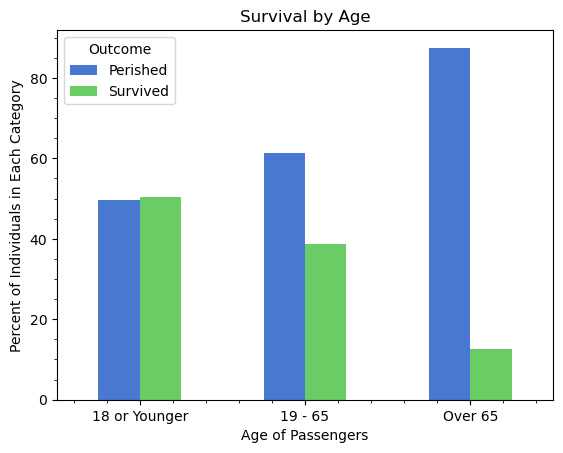

In [28]:
import matplotlib.pyplot as plt
plt.style.use('seaborn-v0_8-muted')
parch_crosstab = pd.crosstab(df['Age_cat'], df['Survived'], normalize='index')*100

parch_crosstab.plot(kind='bar')

plt.title('Survival by Age')
plt.ylabel('Percent of Individuals in Each Category')
positions = [0,1,2]
x_labels = ['18 or Younger','19 - 65', 'Over 65']
plt.xticks(positions,x_labels,rotation=0)

plt.minorticks_on()

plt.xlabel('Age of Passengers')

plt.legend(['Perished', 'Survived'], title='Outcome')

plt.show()


In [10]:
df['Fare'].describe()

count    891.000000
mean      32.204208
std       49.693429
min        0.000000
25%        7.910400
50%       14.454200
75%       31.000000
max      512.329200
Name: Fare, dtype: float64

In [11]:
q25 = df['Fare'].quantile(0.25) 
q50 = df['Fare'].quantile(0.50) 
q75 = df['Fare'].quantile(0.75) 

df.loc[df['Fare'] <= q25, 'Fare_cat'] = 0
df.loc[(df['Fare'] <= q50) & (df['Fare'] > q25), 'Fare_cat'] = 1
df.loc[(df['Fare'] > q50) & (df['Fare'] < q75), 'Fare_cat'] = 2
df.loc[df['Fare'] >= q75, 'Fare_cat'] = 3

pd.crosstab(df['Fare'], df['Fare_cat'])

Fare_cat,0.0,1.0,2.0,3.0
Fare,,,,
0.0000,15,0,0,0
4.0125,1,0,0,0
5.0000,1,0,0,0
6.2375,1,0,0,0
6.4375,1,0,0,0
...,...,...,...,...
227.5250,0,0,0,4
247.5208,0,0,0,2
262.3750,0,0,0,2


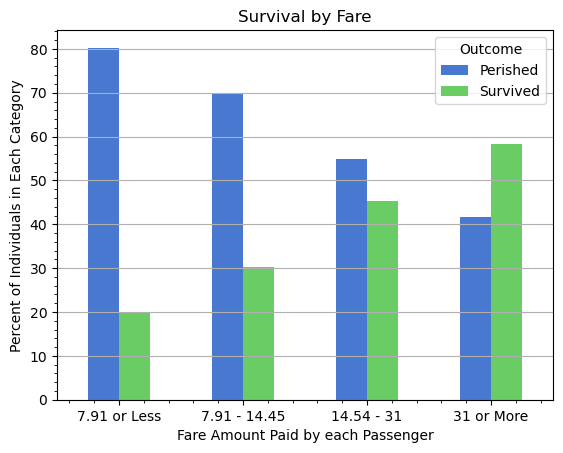

In [12]:
import matplotlib.pyplot as plt

fare_crosstab = pd.crosstab(df['Fare_cat'], df['Survived'], normalize='index')*100

fare_crosstab.plot(kind='bar')

plt.title('Survival by Fare')
plt.ylabel('Percent of Individuals in Each Category')
positions = [0,1,2,3]
x_labels = ['7.91 or Less','7.91 - 14.45', '14.54 - 31', '31 or More']
plt.xticks(positions,x_labels,rotation=0)

plt.minorticks_on()
plt.grid(axis='y')

plt.xlabel('Fare Amount Paid by each Passenger')

plt.legend(['Perished', 'Survived'], title='Outcome')

plt.show()

In [13]:
pd.crosstab(df['Sex'] , df['Survived'])

Survived,0,1
Sex,,
female,81,233
male,468,109


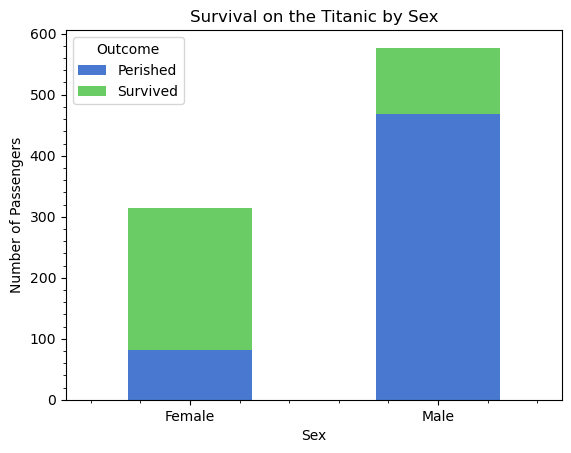

In [25]:
pd.crosstab(df['Sex'] , df['Survived']).plot(kind='bar', stacked=True)

plt.title('Survival on the Titanic by Sex')
plt.ylabel('Number of Passengers')

plt.legend(['Perished', 'Survived'], title='Outcome')
plt.minorticks_on()
current_position =[0,1] #This indicate our first and second tick mark.

x_labels = ["Female" , "Male"]

plt.xticks(current_position, x_labels, rotation=0)


plt.show()

In [15]:
pd.crosstab(df['Pclass'] , df['Survived'])

Survived,0,1
Pclass,,
1,80,136
2,97,87
3,372,119


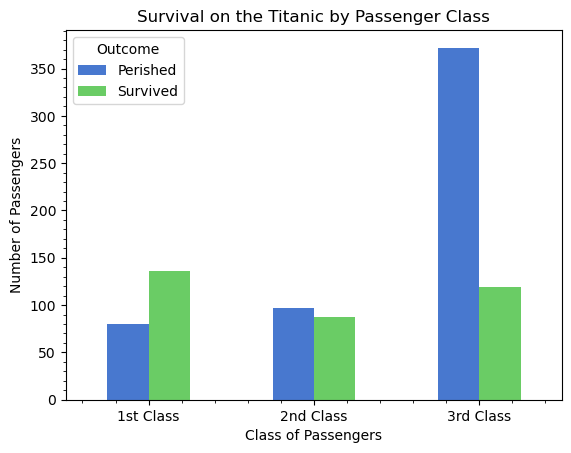

In [16]:
pd.crosstab(df['Pclass'] , df['Survived']).plot(kind='bar')

plt.title('Survival on the Titanic by Passenger Class')
plt.ylabel('Number of Passengers')
plt.xlabel('Class of Passengers')
plt.legend(['Perished', 'Survived'], title='Outcome')
plt.minorticks_on()
current_position =[0,1,2] #This indicate our first and second tick mark.

x_labels = ["1st Class" , "2nd Class", "3rd Class"]

plt.xticks(current_position, x_labels, rotation=0)


plt.show()

In [17]:
df.loc[(df['Parch']) + (df['SibSp']) ==0, 'Parch_cat'] = 0
df.loc[(df['Parch']) + (df['SibSp'])==1, 'Parch_cat'] = 1
df.loc[(df['Parch']) + (df['SibSp']) >= 2, 'Parch_cat'] = 2

pd.crosstab(df['Parch'], df['Parch_cat'])

Parch_cat,0.0,1.0,2.0
Parch,,,
0,537,123,18
1,0,38,80
2,0,0,80
3,0,0,5
4,0,0,4
5,0,0,5
6,0,0,1


In [18]:
pd.crosstab(df['Parch_cat'], df['Survived'])

Survived,0,1
Parch_cat,,
0.0,374,163
1.0,72,89
2.0,103,90


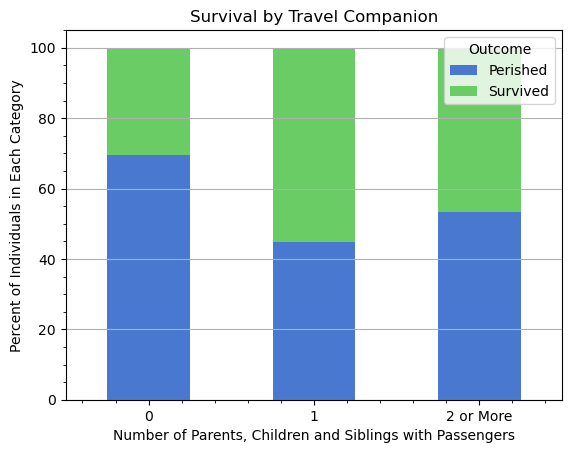

In [26]:
parch_crosstab = pd.crosstab(df['Parch_cat'], df['Survived'], normalize='index')*100

parch_crosstab.plot(kind='bar', stacked=True)

plt.title('Survival by Travel Companion')
plt.ylabel('Percent of Individuals in Each Category')
positions = [0,1,2]
x_labels = ['0','1', '2 or More']
plt.xticks(positions,x_labels,rotation=0)

plt.minorticks_on()
plt.grid(axis='y')

plt.xlabel('Number of Parents, Children and Siblings with Passengers')

plt.legend(['Perished', 'Survived'], title='Outcome')

plt.show()

In [20]:
pd.crosstab(df['Embarked'], df['Survived'])

Survived,0,1
Embarked,,
C,75,93
Q,47,30
S,427,217


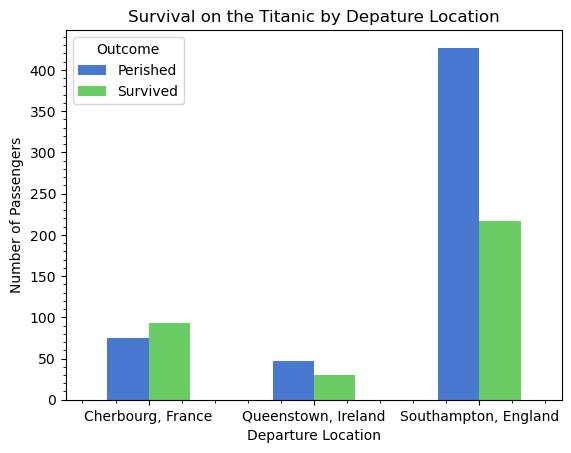

In [21]:
pd.crosstab(df['Embarked'] , df['Survived']).plot(kind='bar')

plt.title('Survival on the Titanic by Depature Location')
plt.ylabel('Number of Passengers')
plt.xlabel('Departure Location')

plt.legend(['Perished', 'Survived'], title='Outcome')
plt.minorticks_on()
current_position =[0,1,2] 

x_labels = ["Cherbourg, France" , "Queenstown, Ireland", "Southampton, England"]

plt.xticks(current_position, x_labels, rotation=0)


plt.show()


In [22]:
sur_df = df [(df['Embarked'] == 'C') & (df['Age'] <= 18) & (df['Fare'] >= 31) &
(df['Sex'] == 'female') & (df['Pclass'] == 1) & (df['Parch']) + (df['SibSp']) == 1]
sur_df.head(10)


,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked,Age_cat,Fare_cat,Parch_cat
307,308,1,1,"Penasco y Castellana, Mrs. Victor de Satode (M...",female,17.0,1,0,PC 17758,108.9000,C65,C,0.0,3.0,1.0
329,330,1,1,"Hippach, Miss. Jean Gertrude",female,16.0,0,1,111361,57.9792,B18,C,0.0,3.0,1.0
700,701,1,1,"Astor, Mrs. John Jacob (Madeleine Talmadge Force)",female,18.0,1,0,PC 17757,227.5250,C62 C64,C,0.0,3.0,1.0


In [29]:
per_df = df [(df['Embarked'] == 'S') & (df['Age'] > 65) & (df['Fare'] <= 7.92) &
(df['Sex'] == 'male') & (df['Pclass'] == 3) & (df['Parch'] == 0 ) & (df['SibSp']==0)]
per_df.head(10)

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked,Age_cat,Fare_cat,Parch_cat
851,852,0,3,"Svensson, Mr. Johan",male,74.0,0,0,347060,7.775,NaN,S,2.0,0.0,0.0


In [24]:
#Most likely to survive
#Miss.Gertrude Hippach
#An interesting fact about Gertrude Isabelle Hippach is that before surviving the Titanic disaster in 1912,
#she had already lived through another tragedy, the Iroquois Theatre fire of 1903, where two of her brothers died.
#By the time she was 18, she had experienced two of the most famous disasters of the early 1900s.
#Despite this, she continued to travel and even returned to Europe a year after the Titanic sank.

In [ ]:
#Most Likely to Perish
#Mr. Johan Svensson
#An interesting fact about Johan Svensson is that he was the oldest passenger aboard the Titanic, at 74 years old. 
#After losing his wife just two months before the voyage, he reluctantly agreed to leave his home in Sweden to join his son in South Dakota.
#Sadly, both he and his son died in the sinking, and their bodies were never identified.